In [24]:
import matplotlib.pyplot as plt
import polars as pl
import polars.selectors as cs

from src.data.ohlcv_query import load_ohlcv_range
from src.stats.vif import variance_inflation_factor
from src.technical_indicators import add_indicators


In [ ]:

df: pl.DataFrame = load_ohlcv_range(
    data_dir="../data/",
    symbol="AAVE/USDC",
    timeframe="5m"
)

timeframes: list[str] = ["5m", "15m", "30m", "1h", "2h", "6h", "1d"]

atr_periods: list[int] = [7, 14, 21, 28]
adx_periods: list[int] = [7, 14, 21, 28]
ppo_periods: list[int] = [7, 14, 21, 28]
rsi_periods: list[int] = [7, 14, 21, 28]

adx_indicators: list[tuple[str, str, dict[str, int]]] = [
    ("adx", tf, {"timeperiod": period})
    for tf in timeframes
    for period in adx_periods
]

atr_indicators: list[tuple[str, str, dict[str, int]]] = [
    ("atr", tf, {"timeperiod": period})
    for tf in timeframes
    for period in atr_periods
]

ppo_indicators: list[tuple[str, str, dict[str, int]]] = [
    ("ppo", tf, {"timeperiod": period})
    for tf in timeframes
    for period in ppo_periods
]
rsi_indicators: list[tuple[str, str, dict[str, int]]] = [
    ("rsi", tf, {"timeperiod": period})
    for tf in timeframes
    for period in rsi_periods
]

combined: list[tuple[str, str, dict[str, int]]] = adx_indicators + atr_indicators + ppo_indicators + rsi_indicators
df_with_features: pl.DataFrame = add_indicators(df, indicators=combined, base_timeframe="5m")

In [26]:
df_with_features = df_with_features.drop_nans()
df_num = df_with_features.select(cs.numeric())

In [27]:
vif = variance_inflation_factor(df=df_num)

In [32]:
print(vif.filter(
    pl.col("VIF") < 5,
    # pl.col("feature").str.contains("atr")
    ))

shape: (9, 2)
┌──────────────┬──────────┐
│ feature      ┆ VIF      │
│ ---          ┆ ---      │
│ str          ┆ f64      │
╞══════════════╪══════════╡
│ volume       ┆ 1.362515 │
│ adx_7_30m    ┆ 4.070561 │
│ adx_7_1h     ┆ 2.509467 │
│ adx_7_2h     ┆ 1.710201 │
│ ppo_12_26_2h ┆ 2.510118 │
│ ppo_12_26_6h ┆ 1.388072 │
│ ppo_12_26_1d ┆ 1.144372 │
│ rsi_7_1d     ┆ 1.680673 │
│ rsi_14_1d    ┆ 3.714386 │
└──────────────┴──────────┘


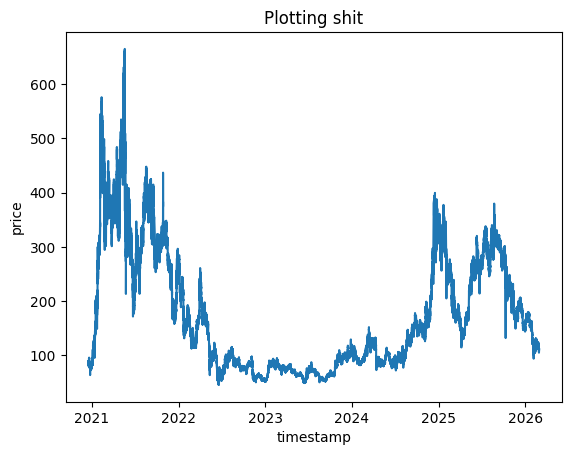

In [11]:
# Pass the timestamp series as X and the close series as Y
df = df.sort("timestamp")
plt.plot(df["timestamp"], df["close"])

plt.xlabel("timestamp")
plt.ylabel("price")
plt.title("Plotting shit")
plt.show()